In [1]:
import urllib.request
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#loading the data
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
stars_csv = pd.read_csv('stars.csv')
stars_csv

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [3]:
# Assign unique integers from 0 to 6 to each star type

le = LabelEncoder()
stars_csv['Star type'] = le.fit_transform(stars_csv['Star type'])
labels = le.inverse_transform(stars_csv['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


Let's do a preliminary scatter plot of the temperature and luminosity of the stars in the sample

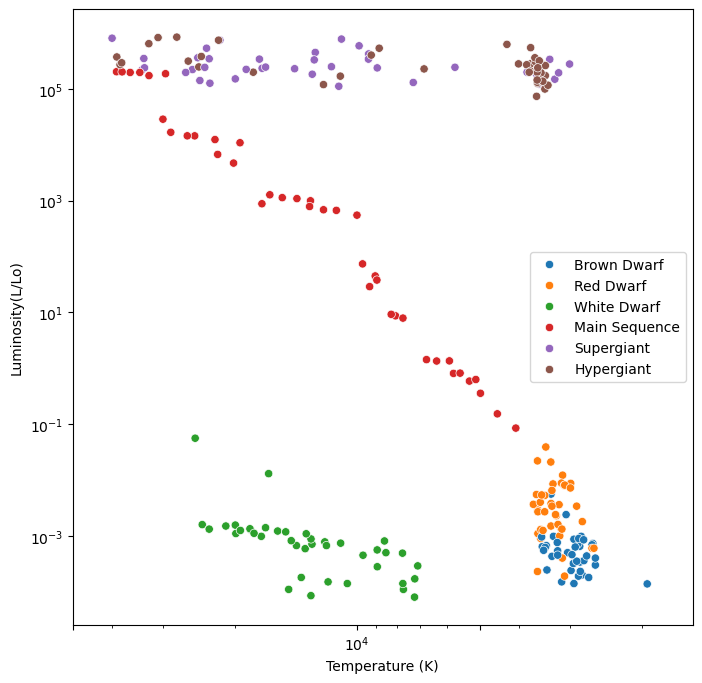

In [4]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=stars_csv, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

As expected we obtain the structure of the HR diagram

We now consider as data the temperature, luminosity, radius and absolute magnitude.

We perform principal component analysis.

In [5]:
# getting the data in sklearn format
sk_data = []
for i in range(240):
    sk_data.append([stars_csv.iloc[i, 0], stars_csv.iloc[i, 1], stars_csv.iloc[i, 2], stars_csv.iloc[i, 3],])

sk_data = np.array(sk_data)

In [6]:
#principal component analysis
n_components = 4
pca = PCA(n_components=n_components)
princ_comp = pca.fit_transform(sk_data) #coordinates in the new basis
eigenvectors = pca.components_ # new basis

Let's do a ascatter plot considering the first two principal components

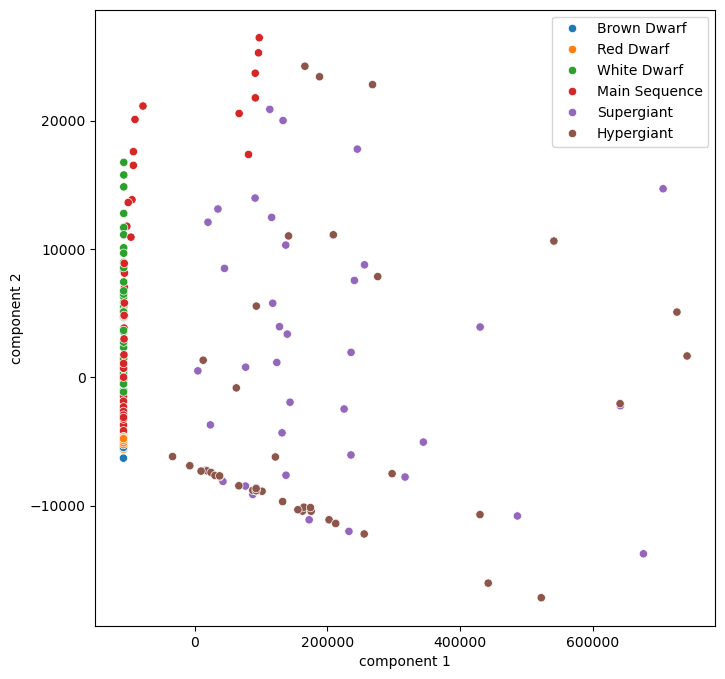

In [7]:
fig = plt.figure(figsize=(8, 8))
sns.scatterplot(x=princ_comp[:, 0], y=princ_comp[:, 1], hue=labels)
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.show()

The plot looks messy, to clean it up we repeat the analysis after having standaardized the data (mean=0, variance=1 for each dimension)

In [8]:
scaler = StandardScaler()
sk_data_scaled = scaler.fit_transform(sk_data) 
pca.fit(sk_data_scaled)
princ_comp_scaled = pca.transform(sk_data_scaled)
eigenvectors_scaled = pca.components_

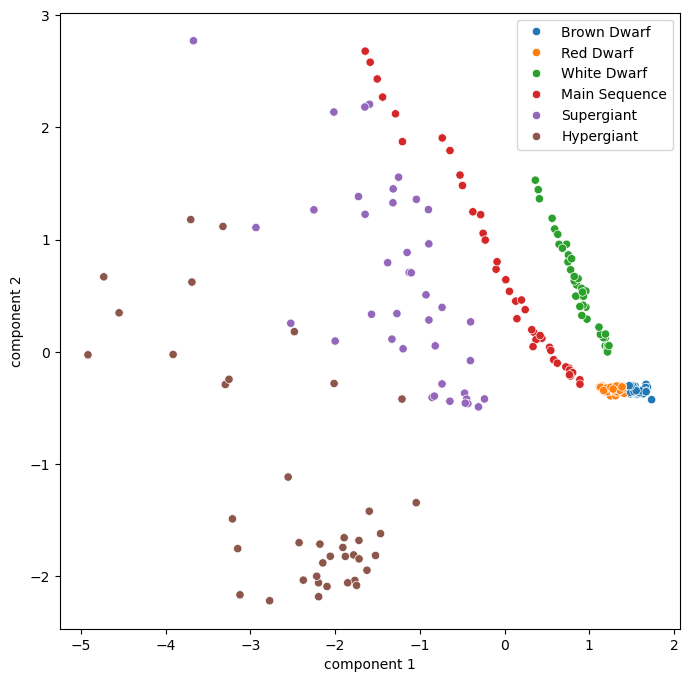

In [9]:
fig = plt.figure(figsize=(8, 8))
sns.scatterplot(x=princ_comp_scaled[:, 0], y=princ_comp_scaled[:, 1], hue=labels)
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.show()

The percentage of the variance we are able to capture by considering a given number of components is:

Text(0, 0.5, 'cumulative explained variance ratio')

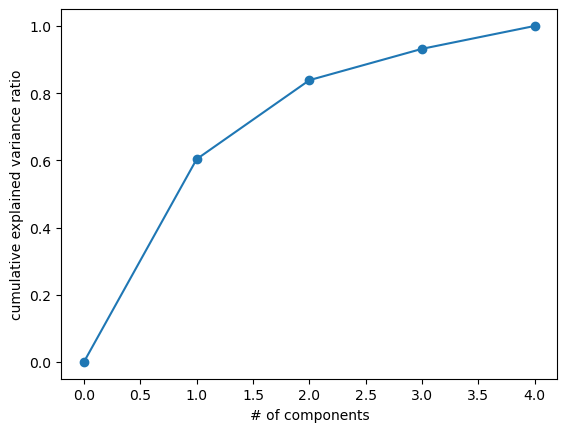

In [10]:
x_ticks = np.arange(0, n_components+1)
exp_var = np.cumsum(pca.explained_variance_ratio_)
y = np.concatenate((np.array([0.]), exp_var))

#plot
plt.plot(x_ticks, y)
plt.scatter(x_ticks, y)
plt.ylim(-0.05, 1.05)
plt.xlabel('# of components')
plt.ylabel('cumulative explained variance ratio')

In [11]:
#cumulative variance ratio in the first two components
print(exp_var[1])

0.838581750804348


Considering the first two principal components we are able to explain around $84\%$ of the variance in the data

Lastlt let's try with a non linear dimensionality reduction techinique (t- SNE):

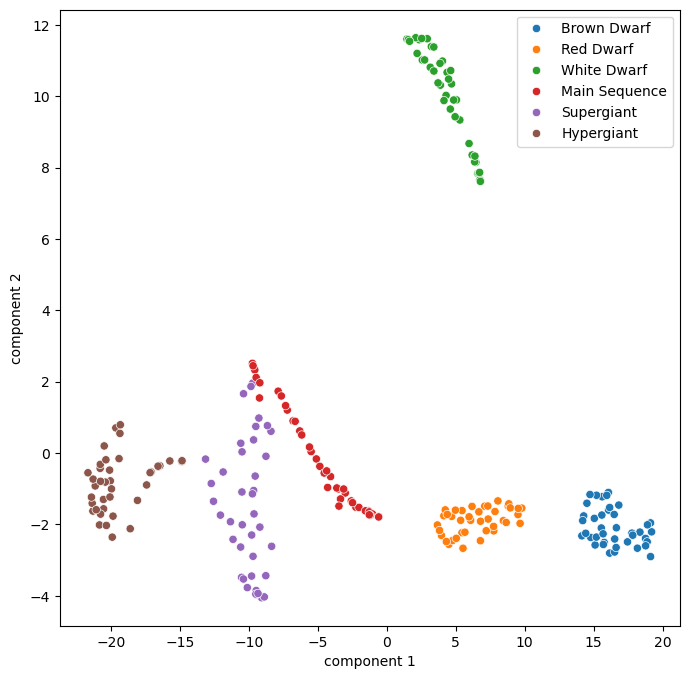

In [16]:
tsne = TSNE(n_components=2, learning_rate=10)
tsne_data = tsne.fit_transform(sk_data_scaled)

#plot
fig = plt.figure(figsize=(8, 8))
sns.scatterplot(x=tsne_data[:, 0], y=tsne_data[:, 1], hue=labels)
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.show()